In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import f_oneway
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [ ]:
hashtag = pd.read_csv('hashtag_frequency.csv')
df = pd.read_csv('full_data.csv')

## Data Wrangling

### Hashtag Frequency Dataset

In [3]:
hashtag.shape

(3021, 2)

In [5]:
hashtag.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3021 entries, 0 to 3020
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tags       3020 non-null   object
 1   frequency  3021 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.3+ KB


In [6]:
hashtag.dropna(inplace = True)

In [7]:
hashtag.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3020 entries, 1 to 3020
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tags       3020 non-null   object
 1   frequency  3020 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 70.8+ KB


In [8]:
hashtag.head(10)

,tags,frequency
1,london,363
2,bricklane,289
3,streetart,166
4,shoreditch,104
5,graffiti,101
6,eastlondon,85
7,art,70
8,streetphotography,51
9,vscocam,51
10,fashion,49


### Full Dataset

In [12]:
df.shape

(1239, 24)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 24 columns):
 #   Column                                                                                                                                                                                                 Non-Null Count  Dtype  
---  ------                                                                                                                                                                                                 --------------  -----  
 0   {"error":"a fatal error was encountered","eid":"e56e2e6aca1e54"}{"error":"a fatal error was encountered","eid":"e56e2e6accb996"}{"error":"a fatal error was encountered","eid":"e56e2e6acee6d0"}query  1236 non-null   object 
 1   id                                                                                                                                                                                                     1238 

In [14]:
df = df.drop(df.columns[0], axis = 1)

In [15]:
df = df.drop(['videos', 'videos_name', 'location_name', 'user_website', 'user_bio', 'attribution', 'user_full_name', 'user_profile_picture'], axis = 1)

In [16]:
df = df[df['type'] == 'image']

In [17]:
df = df[df['users_in_photo'] >= 0]

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1185 entries, 0 to 1238
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              1185 non-null   object 
 1   type            1185 non-null   object 
 2   created_time    1185 non-null   object 
 3   link            1185 non-null   object 
 4   images          1185 non-null   object 
 5   images_name     1185 non-null   object 
 6   likes           1185 non-null   float64
 7   comments        1185 non-null   object 
 8   tags            833 non-null    object 
 9   caption_text    1087 non-null   object 
 10  location        1185 non-null   object 
 11  user_username   1185 non-null   object 
 12  user_id         1185 non-null   float64
 13  filter          1185 non-null   object 
 14  users_in_photo  1185 non-null   float64
dtypes: float64(3), object(12)
memory usage: 148.1+ KB


## Quantitative Analysis

### Sentiment Analysis

In [22]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    if score['compound'] >= 0.05:
        return "positive"
    elif score['compound'] <= -0.05:
        return "negative"
    else:
        return "neutral"

hashtag['sentiment'] = hashtag['tags'].apply(get_sentiment)

In [23]:
print(hashtag['sentiment'].value_counts())

sentiment
neutral     2899
positive      94
negative      27
Name: count, dtype: int64


In [26]:
hashtag.head(35)

,tags,frequency,sentiment
1,london,363,neutral
2,bricklane,289,neutral
3,streetart,166,neutral
4,shoreditch,104,neutral
5,graffiti,101,neutral
6,eastlondon,85,neutral
7,art,70,neutral
8,streetphotography,51,neutral
9,vscocam,51,neutral
10,fashion,49,neutral


### Thematic Analysis

In [9]:
# Expand hashtags based on frequency to reflect weight
hashtags_weighted = []
for tag, freq in zip(hashtag['tags'], hashtag['frequency']):
    hashtags_weighted.extend([tag] * int(freq))

In [10]:
# Fit BERTopic model
vectorizer_model = CountVectorizer(ngram_range=(1, 1), stop_words="english")
topic_model = BERTopic(vectorizer_model=vectorizer_model)
topics, probs = topic_model.fit_transform(hashtags_weighted)

In [11]:
# View topic summary
topic_info = topic_model.get_topic_info()
print(topic_info.head(10))

   Topic  Count                                               Name  \
0     -1    757       -1_streetstyle_hasbro_nofilter_timeoutlondon   
1      0    377           0_london_londonescape_london2016_hackney   
2      1    316             1_bricklane_lane_bricklaneart_briklane   
3      2    185           2_streetart_wallart_streetartuk_traveluk   
4      3    126  3_shoreditch_ragyard_shoreditchstreetart_havef...   
5      4    118  4_graffiti_graffitiworld_graffitihood_graffiti...   
6      5    104                  5_storyoflola_roa_gullysteez_moda   
7      6     82             6_art_lovesart_illustriousart_artistic   
8      7     81  7_photography_photographer_photographs_photoshoot   
9      8     76  8_fashion_fashionstreet_fashionschool_fashions...   

                                      Representation  \
0  [streetstyle, hasbro, nofilter, timeoutlondon,...   
1  [london, londonescape, london2016, hackney, lo...   
2  [bricklane, lane, bricklaneart, briklane, bric...   
3  [s

In [12]:
# Visualize the topics in browser 
topic_model.visualize_topics()

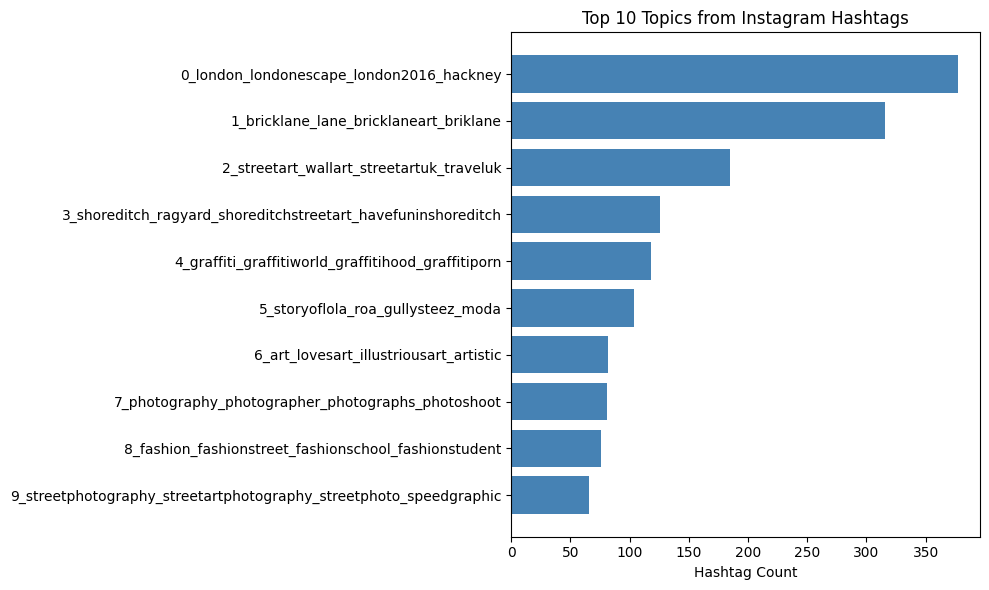

In [13]:
topic_info = topic_model.get_topic_info()

topic_info = topic_info[topic_info['Topic'] != -1]

top_n = 10
top_topics = topic_info.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_topics['Name'][::-1], top_topics['Count'][::-1], color='steelblue')
plt.xlabel("Hashtag Count")
plt.title(f"Top {top_n} Topics from Instagram Hashtags")
plt.tight_layout()
plt.show()

### Tags Engagement Analysis

#### Tags vs. Likes & Comments

In [27]:
# Split tags into lists
df['tags'] = df['tags'].apply(lambda x: x.split(',') if isinstance(x, str) else [])

In [28]:
# Explode tags into individual rows
df_exploded = df.explode('tags')
df_exploded['tags'] = df_exploded['tags'].str.strip().str.lower()  # Clean and normalize

In [29]:
# Compute average likes and comments per tag
df_exploded['likes'] = pd.to_numeric(df_exploded['likes'], errors='coerce')
df_exploded['comments'] = pd.to_numeric(df_exploded['comments'], errors='coerce')

tag_stats = df_exploded.groupby('tags')[['likes', 'comments']].mean()
tag_stats['count'] = df_exploded['tags'].value_counts()

In [30]:
# Display top 10 tags by average likes
top_likes = tag_stats.sort_values(by='likes', ascending=False).head(10)
top_comments = tag_stats.sort_values(by='comments', ascending=False).head(10)

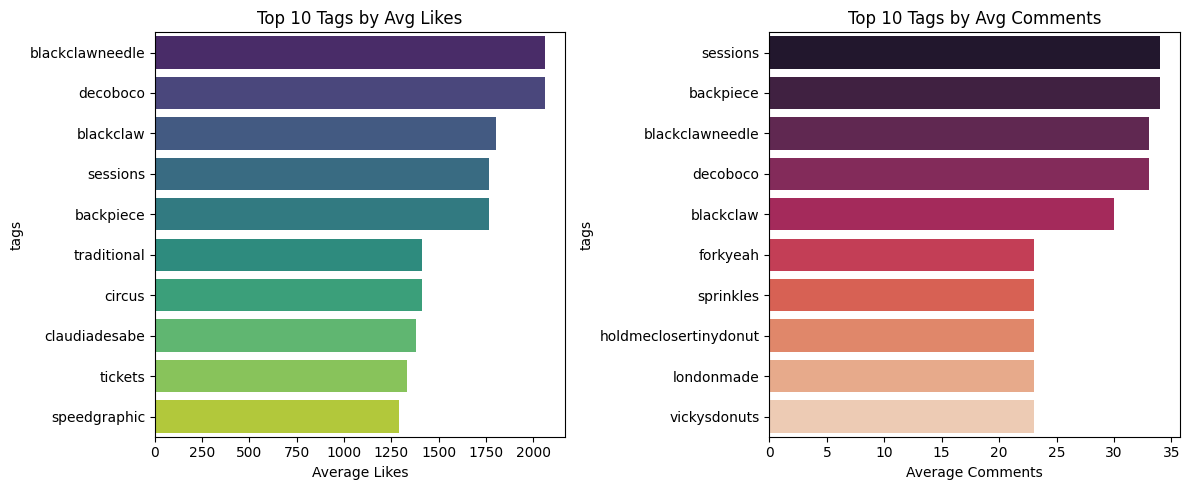

In [31]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=top_likes['likes'], y=top_likes.index, palette='viridis')
plt.title('Top 10 Tags by Avg Likes')
plt.xlabel('Average Likes')

plt.subplot(1, 2, 2)
sns.barplot(x=top_comments['comments'], y=top_comments.index, palette='rocket')
plt.title('Top 10 Tags by Avg Comments')
plt.xlabel('Average Comments')

plt.tight_layout()
plt.show()

In [32]:
# Filter to most common tags (e.g., those with at least 10 posts)
common_tags = df_exploded['tags'].value_counts()
common_tags = common_tags[common_tags >= 10].index

# Prepare data for ANOVA
anova_data = [df_exploded[df_exploded['tags'] == tag]['likes'] for tag in common_tags]

# Run ANOVA
f_stat, p_value = f_oneway(*anova_data)
print(f"ANOVA F-statistic: {f_stat:.3f}, p-value: {p_value}")
if p_value < 0.05:
    print("Result: Significant differences in likes between tags.")
else:
    print("Result: No significant difference in likes between tags.")

ANOVA F-statistic: 14.364, p-value: 2.5509274042383667e-156
Result: Significant differences in likes between tags.


#### Filters vs. Tags

In [33]:
# Count number of tags per post
df['num_tags'] = df['tags'].apply(lambda x: len(x) if isinstance(x, list) else 0)

In [38]:
# Return list of most frequently used filters
frequency_list = Counter(df['filter']).most_common()
print([item[0] for item in frequency_list])

['Normal', 'Clarendon', 'Juno', 'Lark', 'Gingham', 'Ludwig', 'Valencia', 'Lo-fi', 'Moon', 'Mayfair', 'Amaro', 'X-Pro II', 'Hudson', 'Slumber', 'Inkwell', 'Hefe', 'Reyes', 'Rise', 'Aden', 'Crema', 'Sierra', 'Willow', 'Perpetua', 'Dogpatch', 'Helena', 'Charmes', 'Ginza', 'Earlybird', 'Nashville', 'Kelvin', 'Brannan']


In [39]:
# Group by filter and compute average number of tags
filter_tag_stats = df.groupby('filter')['num_tags'].mean().sort_values(ascending=False)

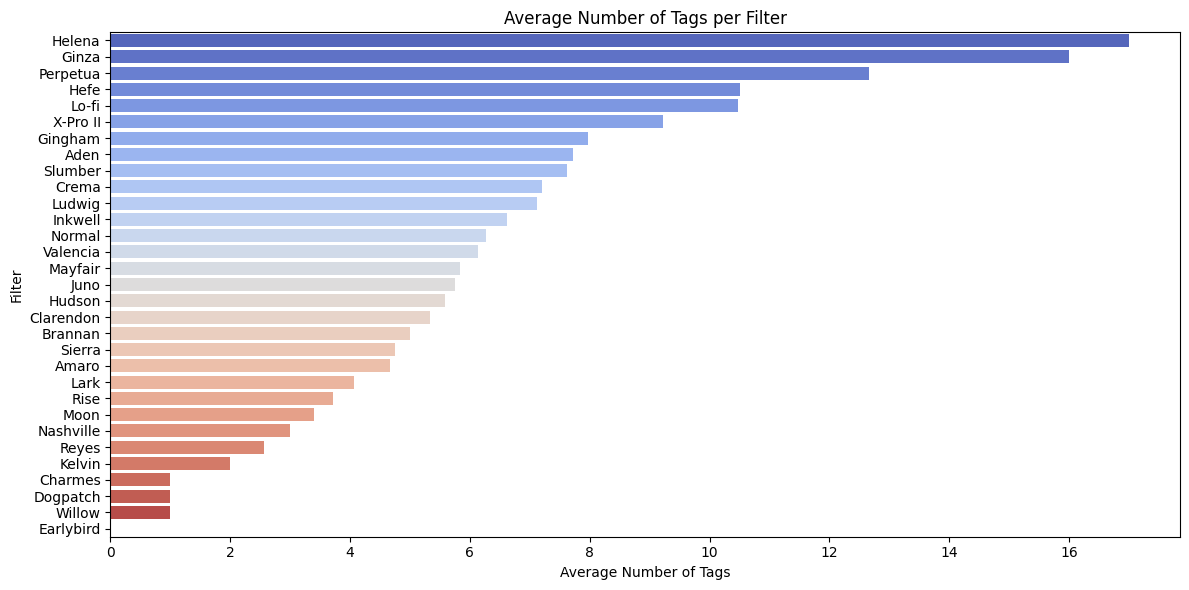

In [40]:
plt.figure(figsize=(12, 6))
sns.barplot(x=filter_tag_stats.values, y=filter_tag_stats.index, palette="coolwarm")
plt.title('Average Number of Tags per Filter')
plt.xlabel('Average Number of Tags')
plt.ylabel('Filter')
plt.tight_layout()
plt.show()

In [41]:
# Group by filter and tag to count occurrences
tag_counts_by_filter = df_exploded.groupby(['filter', 'tags']).size().reset_index(name='count')

In [42]:
# Get top N tags per filter (e.g., top 5)
top_tags_by_filter = (
    tag_counts_by_filter
    .sort_values(['filter', 'count'], ascending=[True, False])
    .groupby('filter')
    .head(5)
)

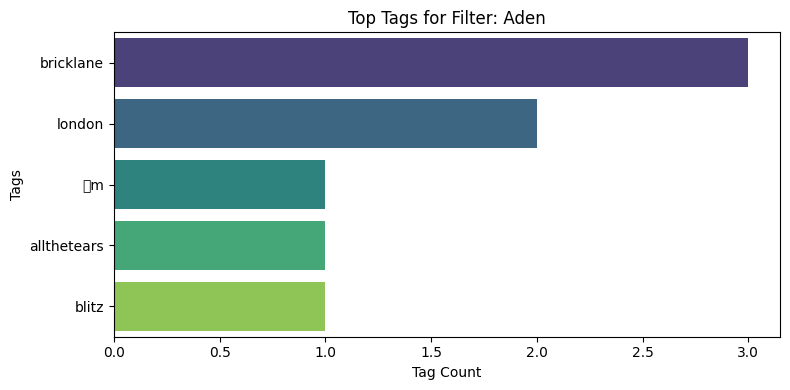

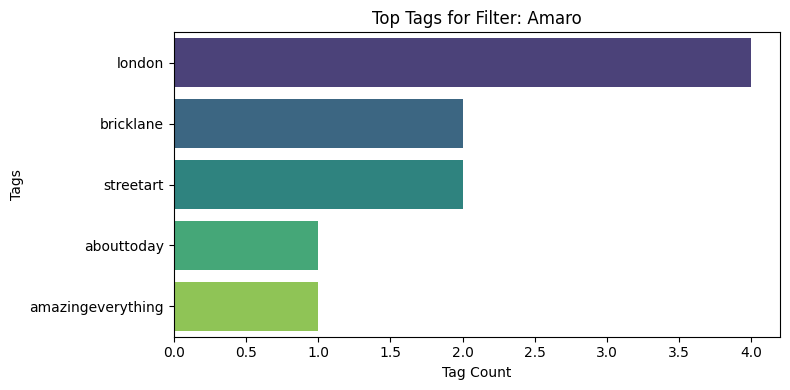

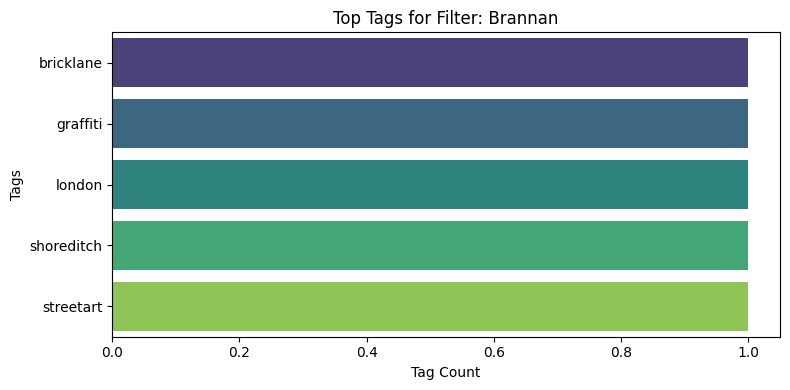

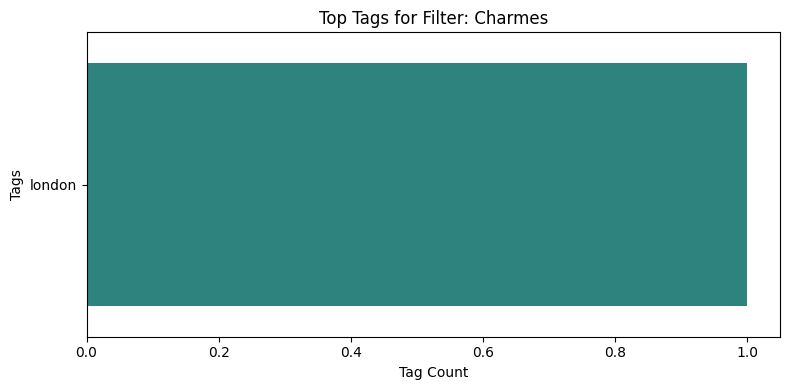

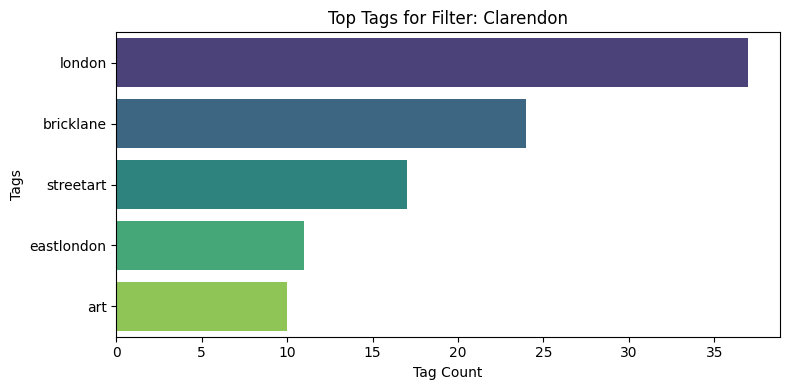

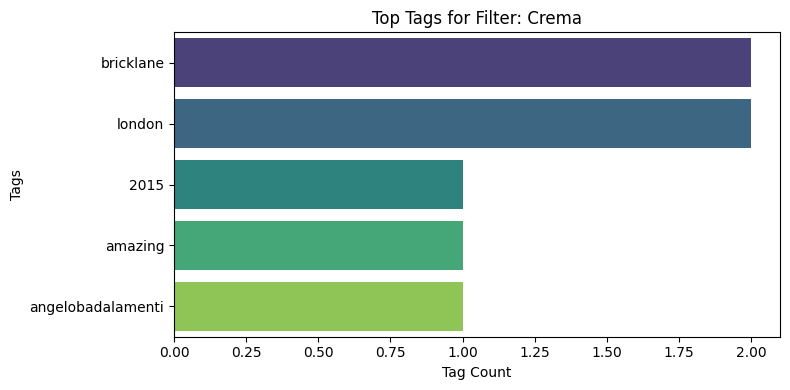

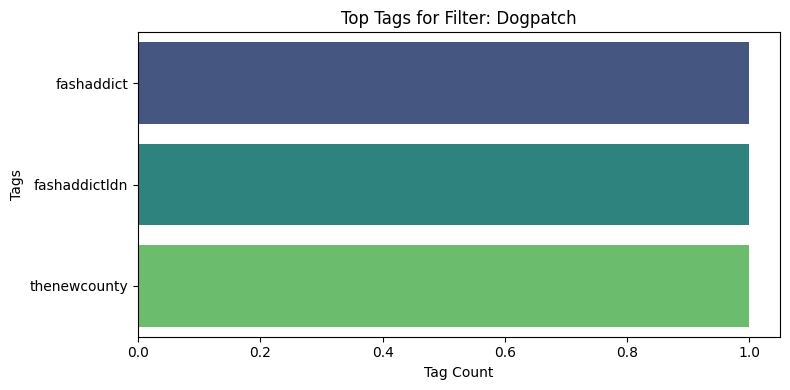

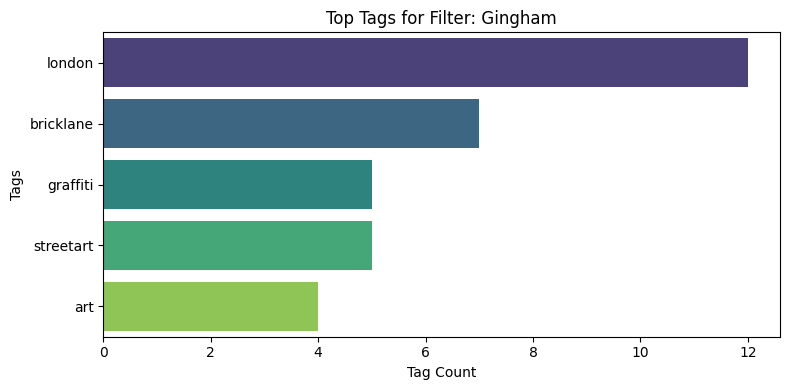

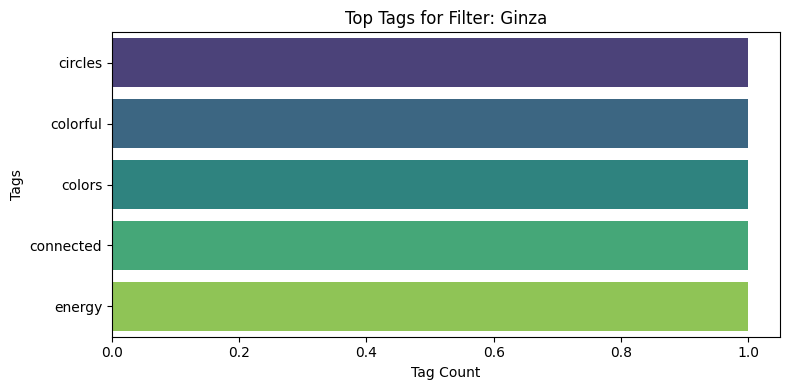

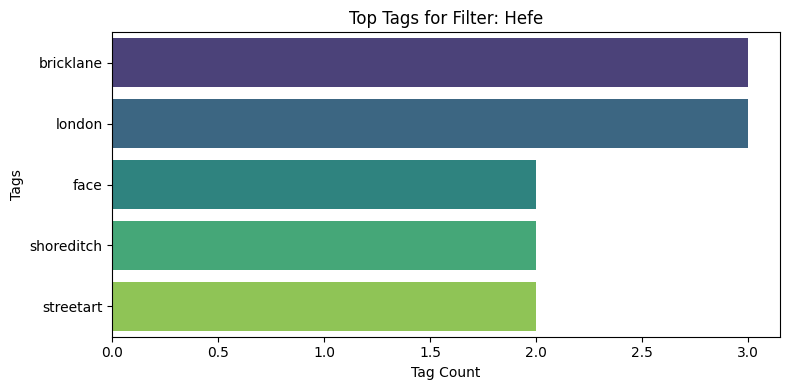

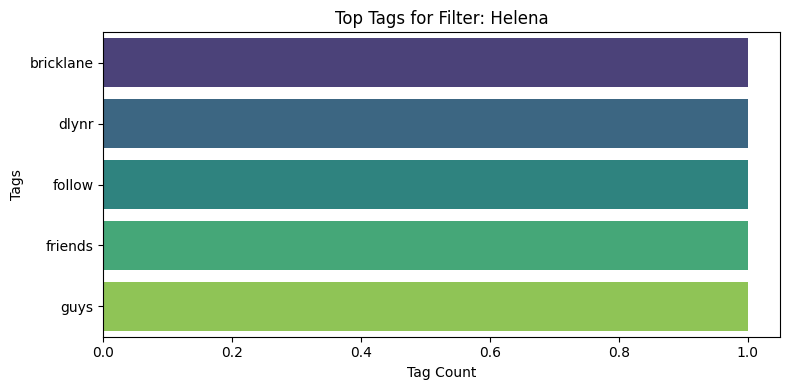

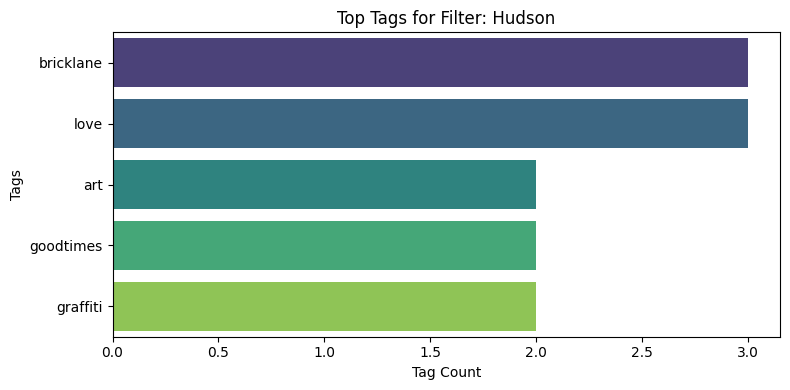

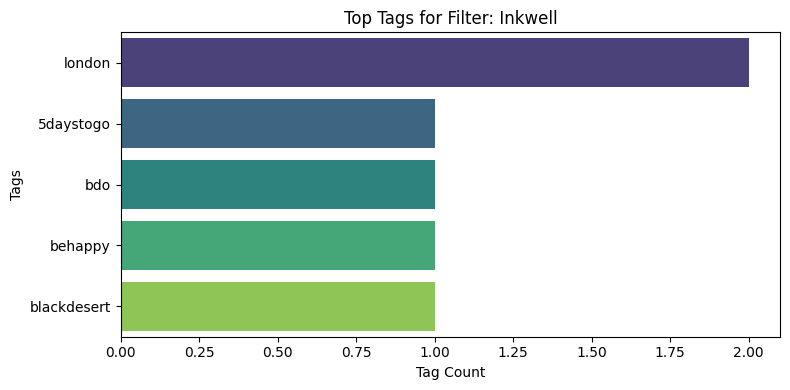

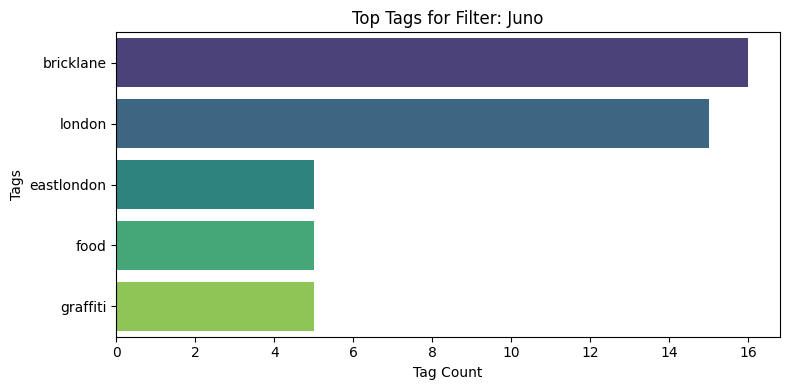

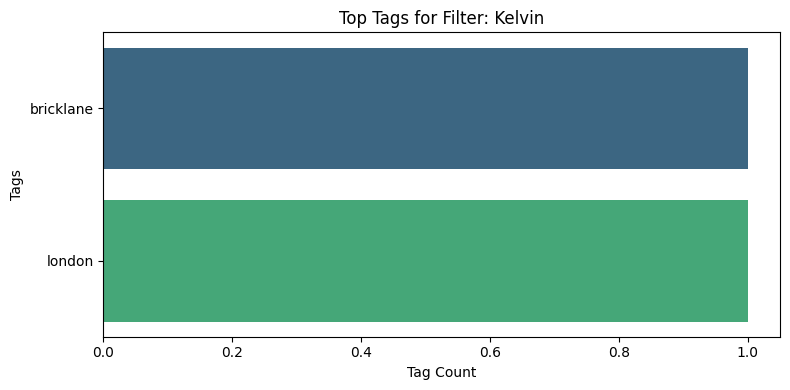

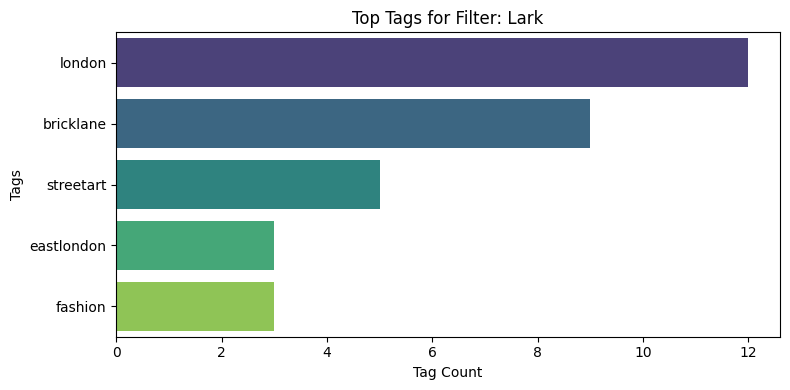

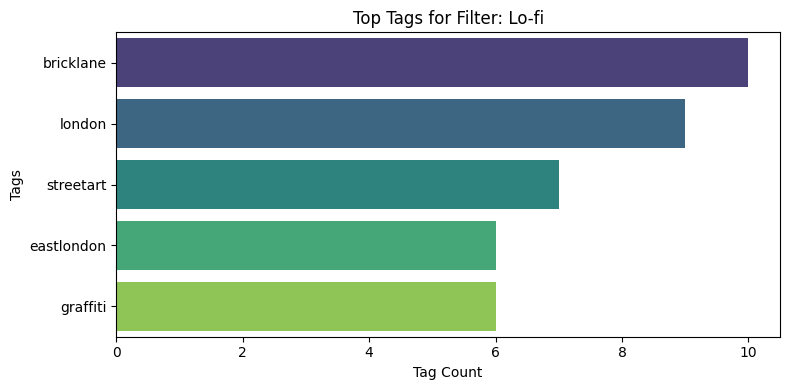

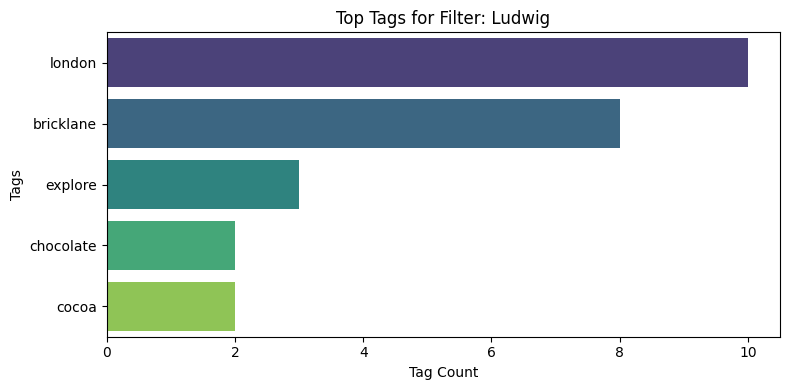

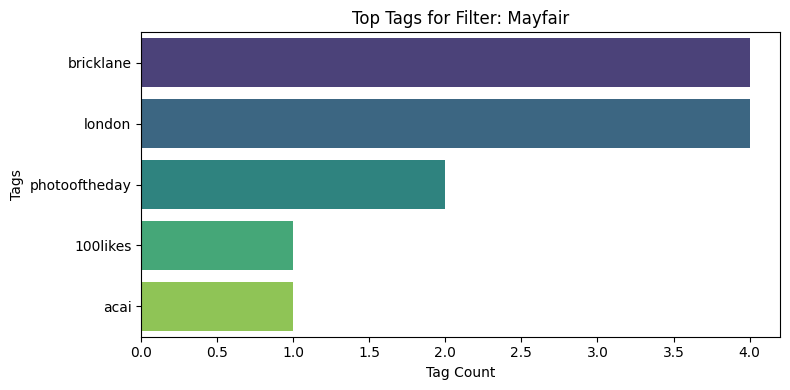

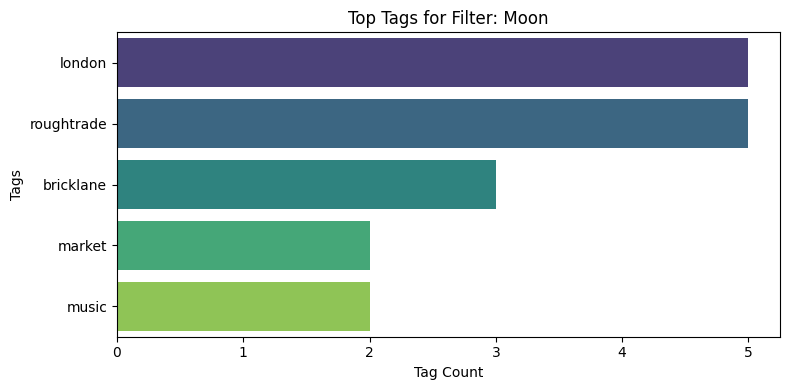

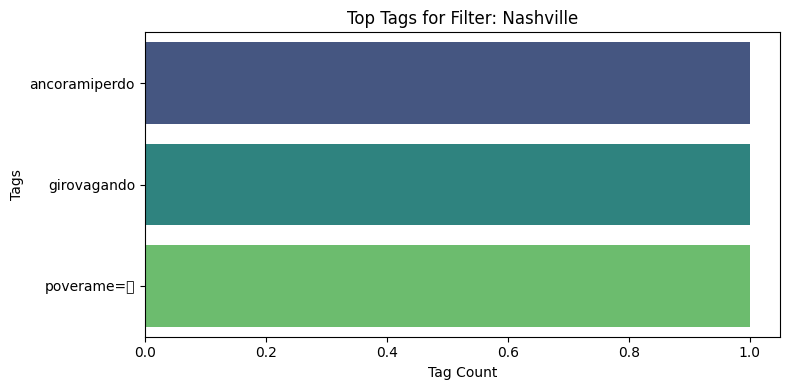

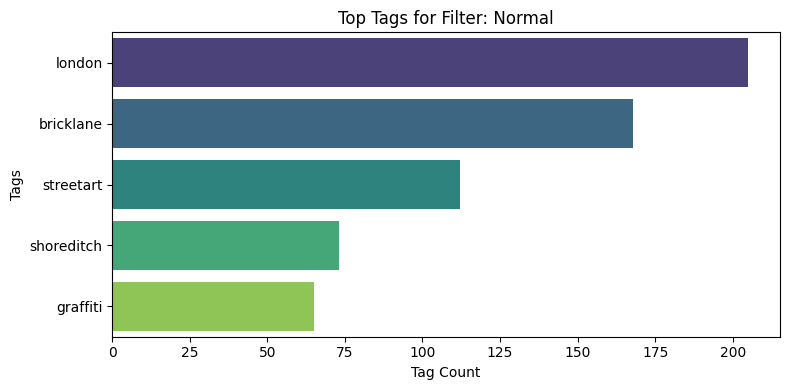

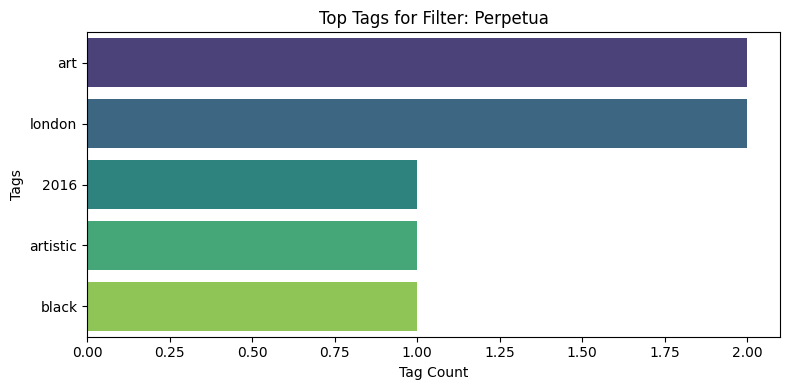

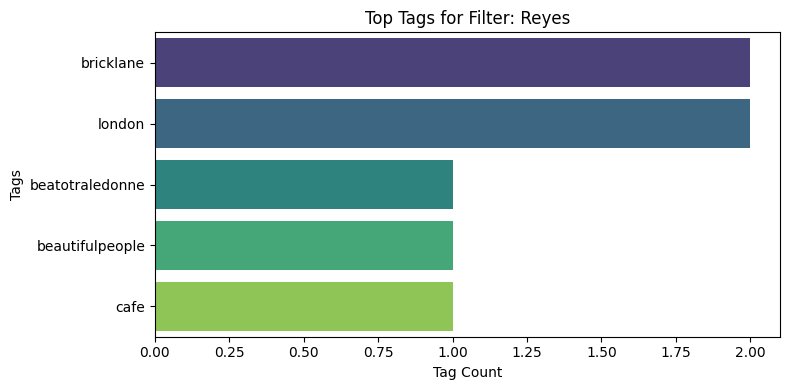

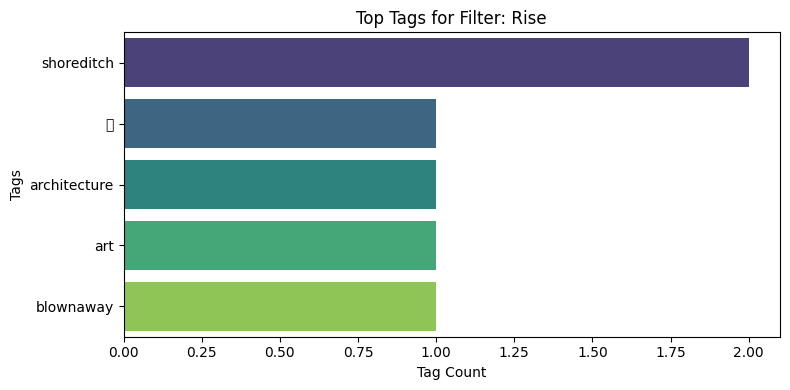

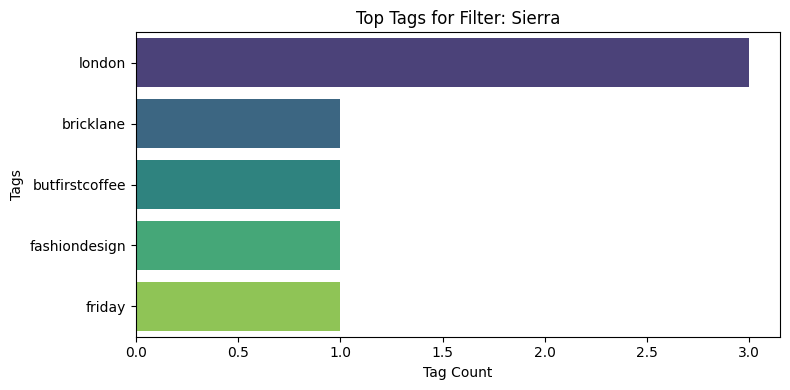

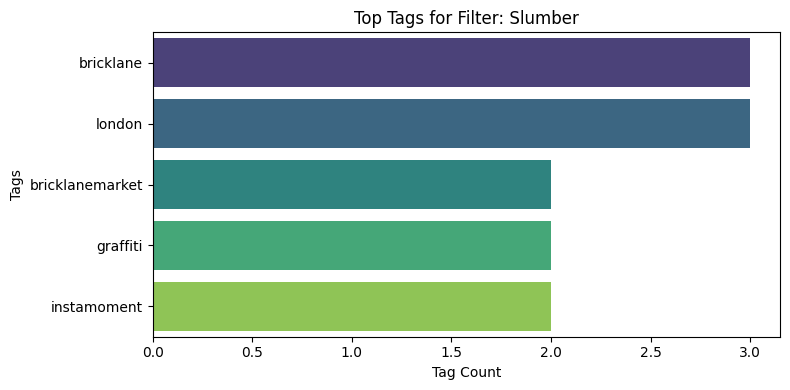

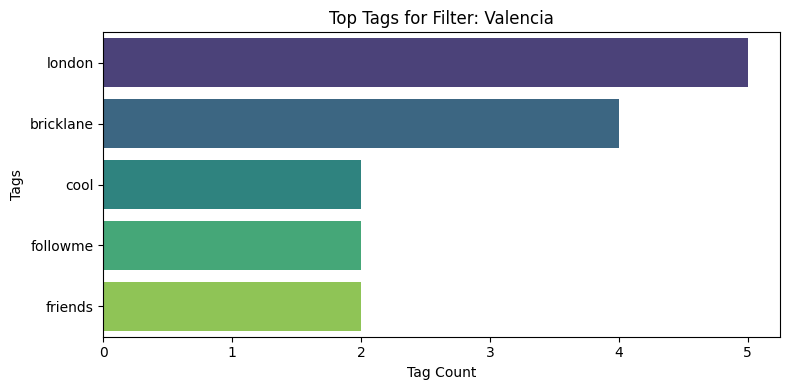

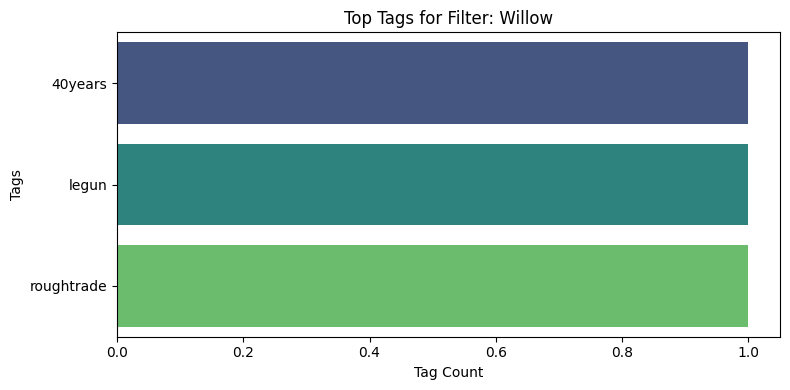

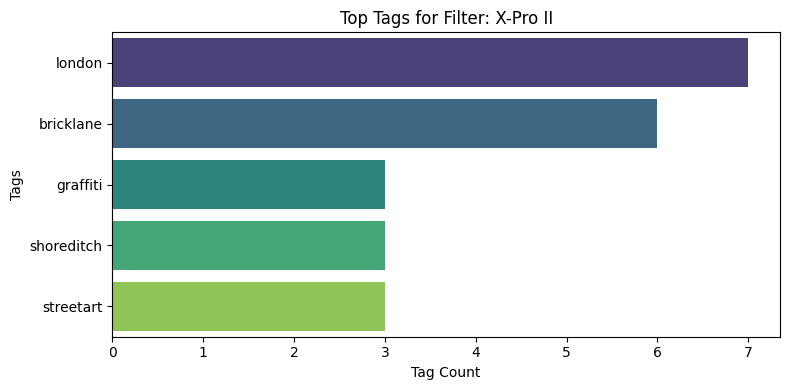

In [43]:
# Get list of unique filters
unique_filters = top_tags_by_filter['filter'].unique()

# Loop through each filter and plot
for f in unique_filters:
    subset = top_tags_by_filter[top_tags_by_filter['filter'] == f]

    plt.figure(figsize=(8, 4))
    sns.barplot(x='count', y='tags', data=subset, palette='viridis')
    plt.title(f'Top Tags for Filter: {f}')
    plt.xlabel('Tag Count')
    plt.ylabel('Tags')
    plt.tight_layout()
    plt.show()

### Post Frequency Analysis

In [44]:
# Convert created_time to datetime
df['created_time'] = pd.to_datetime(df['created_time'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

In [45]:
# Extract day of month and hour
df['day'] = df['created_time'].dt.day
df['hour'] = df['created_time'].dt.hour

In [46]:
# Count posts per hour (aggregated over the month)
posts_per_hour = df['hour'].value_counts().sort_index()
posts_per_hour.index = posts_per_hour.index.astype(int)
posts_per_hour

hour
0     32
1     30
2      9
3      6
5      6
6      2
7      8
8     27
9     39
10    38
11    47
12    92
13    99
14    86
15    84
16    57
17    80
18    94
19    90
20    77
21    61
22    74
23    47
Name: count, dtype: int64

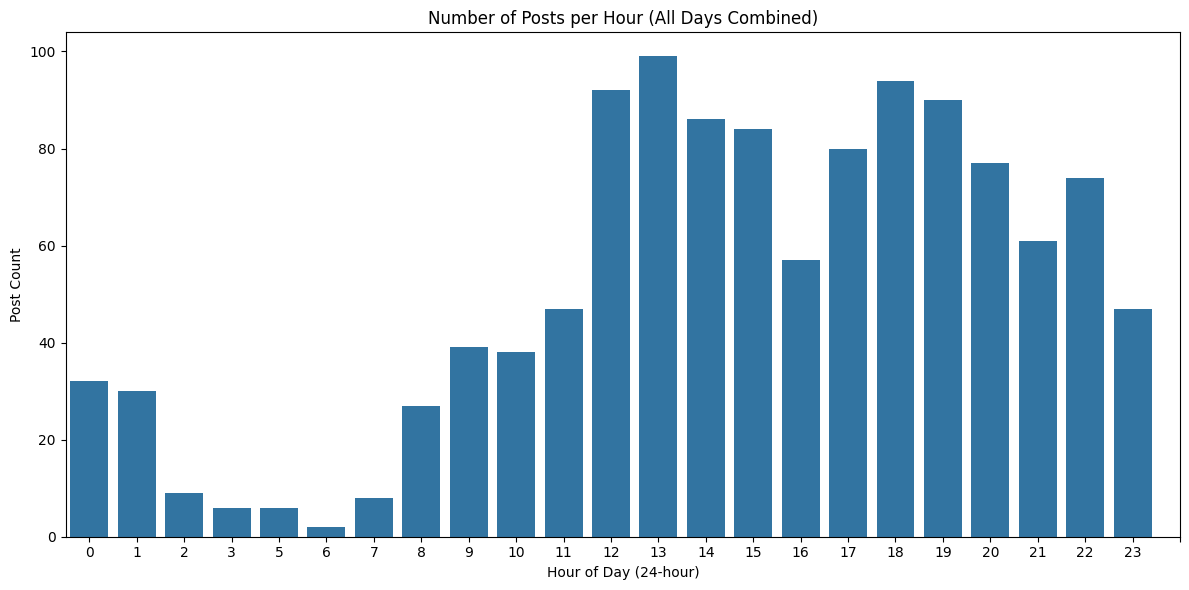

In [47]:
plt.figure(figsize=(12, 6))
sns.barplot(x=posts_per_hour.index, y=posts_per_hour.values)
plt.title('Number of Posts per Hour (All Days Combined)')
plt.xlabel('Hour of Day (24-hour)')
plt.ylabel('Post Count')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [48]:
# Count posts per day
posts_per_day = df['day'].value_counts().sort_index()
posts_per_day.index = posts_per_day.index.astype(int)
posts_per_day

day
7     202
8     296
9     289
10    265
11    133
Name: count, dtype: int64

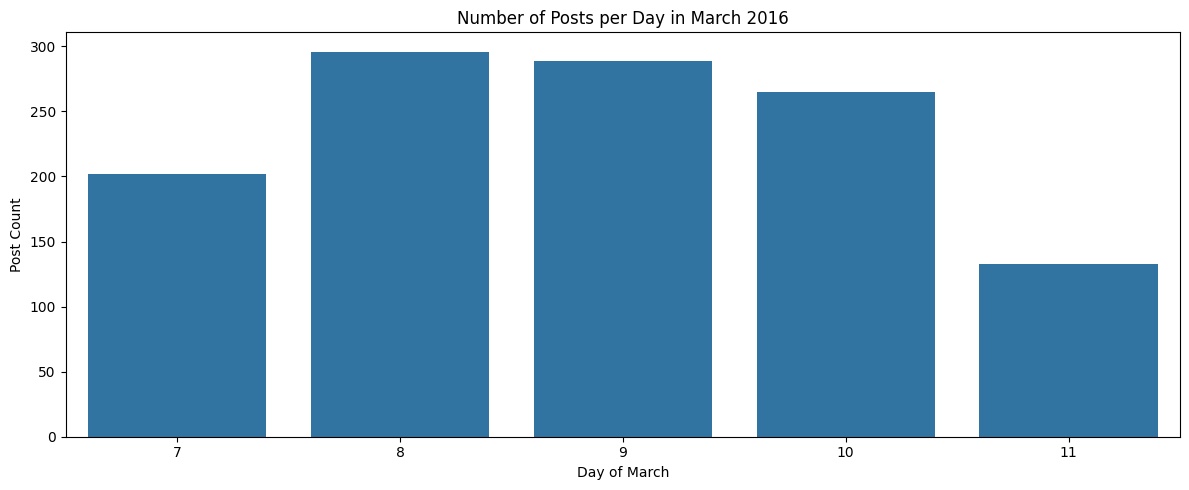

In [49]:
plt.figure(figsize=(12, 5))
sns.barplot(x=posts_per_day.index, y=posts_per_day.values)
plt.title('Number of Posts per Day in March 2016')
plt.xlabel('Day of March')
plt.ylabel('Post Count')
plt.tight_layout()
plt.show()

In [50]:
# Create pivot table: rows = days, columns = hours
heatmap_data = df.pivot_table(index='day', columns='hour', values='created_time', aggfunc='count').fillna(0)

# Make sure row and column labels are integers
heatmap_data.index = heatmap_data.index.astype(int)
heatmap_data.columns = heatmap_data.columns.astype(int)

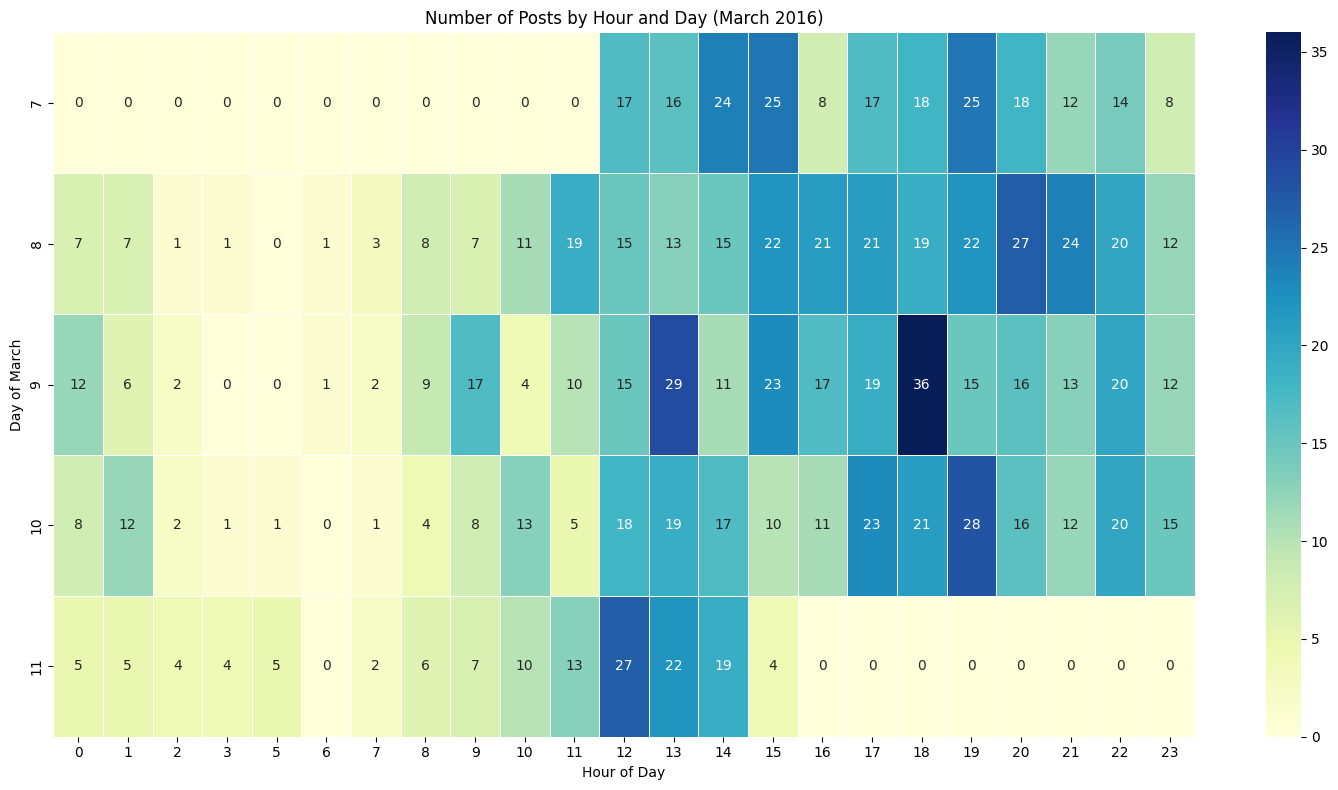

In [51]:
plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.5, annot=True, fmt=".0f")
plt.title('Number of Posts by Hour and Day (March 2016)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of March')
plt.tight_layout()
plt.show()